In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import seaborn as sns

## Workflow

1. Data import
   - Data is RPKM normalized
2. Data wrangling
3. Determining Intra- and Intergroup Sample Variability and Outliers
   - PCA
   - Pearson’s coefficient
   - Spearman’s rank correlation coefficient


In [3]:
df = pd.read_csv("./sample_data/GSE116583_transplant.am.htseq.all.rpkm.txt", sep="\t")
info = pd.read_csv("./sample_data/GSE116583_series_matrix.txt", sep="\t", skiprows=26)
df.head()

,Symbol,N01_AM_Naive_01,N02_AM_Naive_02,N03_AM_Naive_03,N04_AM_Naive_04,R01_AM_Allo_02H_01,R02_AM_Allo_02H_02,R03_AM_Allo_02H_03,R04_AM_Allo_02H_04,R05_AM_Allo_24H_01,R06_AM_Allo_24H_02,R07_AM_Allo_24H_03,R08_AM_Allo_24H_04
0,ENSMUSG00000000001,66.567260,72.604388,67.217287,70.263406,70.839475,64.616903,69.642272,72.673890,68.579085,69.754822,68.286563,68.031853
1,ENSMUSG00000000003,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ENSMUSG00000000028,2.407605,2.163268,2.490079,1.593701,1.441733,1.002870,1.700592,1.666637,11.861413,13.541675,11.626514,9.789112
3,ENSMUSG00000000031,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,ENSMUSG00000000037,0.009852,0.005464,0.017368,0.014177,0.012641,0.000000,0.010085,0.011964,0.028890,0.015992,0.018193,0.018984


In [4]:
info.head()

,!Sample_title,N01_AM_Naive,N02_AM_Naive,N03_AM_Naive,N04_AM_Naive,R01_AM_Allo2h,R02_AM_Allo2h,R03_AM_Allo2h,R04_AM_Allo2h,R05_AM_Allo24h,R06_AM_Allo24h,R07_AM_Allo24h,R08_AM_Allo24h
0,!Sample_geo_accession,GSM3243460,GSM3243461,GSM3243462,GSM3243463,GSM3243464,GSM3243465,GSM3243466,GSM3243467,GSM3243468,GSM3243469,GSM3243470,GSM3243471
1,!Sample_status,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018,Public on Jul 04 2018
2,!Sample_submission_date,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018,Jul 03 2018
3,!Sample_last_update_date,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018,Jul 04 2018
4,!Sample_type,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA,SRA


In [5]:
# Programmatically ensure data is in same order as metadata
dfcols = list(df.columns[1:])
samplerow = (
    info.loc[info["!Sample_title"] == "!Sample_description"].iloc[0].to_list()[1:]
)

assert all(n in m for n, m in zip(df.columns[1:], samplerow))

print(dfcols)
print(samplerow)

['N01_AM_Naive_01', 'N02_AM_Naive_02', 'N03_AM_Naive_03', 'N04_AM_Naive_04', 'R01_AM_Allo_02H_01', 'R02_AM_Allo_02H_02', 'R03_AM_Allo_02H_03', 'R04_AM_Allo_02H_04', 'R05_AM_Allo_24H_01', 'R06_AM_Allo_24H_02', 'R07_AM_Allo_24H_03', 'R08_AM_Allo_24H_04']
['N01_AM_Naive_01_S1', 'N02_AM_Naive_02_S2', 'N03_AM_Naive_03_S3', 'N04_AM_Naive_04_S4', 'R01_AM_Allo_02H_01_S9', 'R02_AM_Allo_02H_02_S10', 'R03_AM_Allo_02H_03_S11', 'R04_AM_Allo_02H_04_S12', 'R05_AM_Allo_24H_01_S17', 'R06_AM_Allo_24H_02_S18', 'R07_AM_Allo_24H_03_S19', 'R08_AM_Allo_24H_04_S20']


In [6]:
# Rename df columns
cols = [
    "Naive_01",
    "Naive_02",
    "Naive_03",
    "Naive_04",
    "Transplant_2h_01",
    "Transplant_2h_02",
    "Transplant_2h_03",
    "Transplant_2h_04",
    "Transplant_24h_05",
    "Transplant_24h_06",
    "Transplant_24h_07",
    "Transplant_24h_08",
]

df = df.set_axis(
    ["Symbol"] + cols,
    axis=1,
)

dfcounts = df.copy().drop(columns=["Symbol"])

# Log-transform data and transpose dataframe for PCA
dfnorm = dfcounts.apply(lambda x: np.log10(x + 1))

scaler = StandardScaler()
data_scaled = scaler.fit_transform(dfnorm)
dfscaled = pd.DataFrame(data_scaled, columns=dfnorm.columns)
df_T = dfscaled.T

## PCA


In [7]:
pca = PCA()
pca_results = pca.fit_transform(df_T)

explained_variance = pca.explained_variance_ratio_

groups = df_T.index.str.replace(r"_\d+$", "", regex=True)
df_pca = pd.DataFrame(
    {
        "PC1": pca_results[:, 0],
        "PC2": pca_results[:, 1],
        "Group": groups,
        "Sample": df_T.index,
    }
)

Text(0, 0.5, 'Explained Variance (in %)')

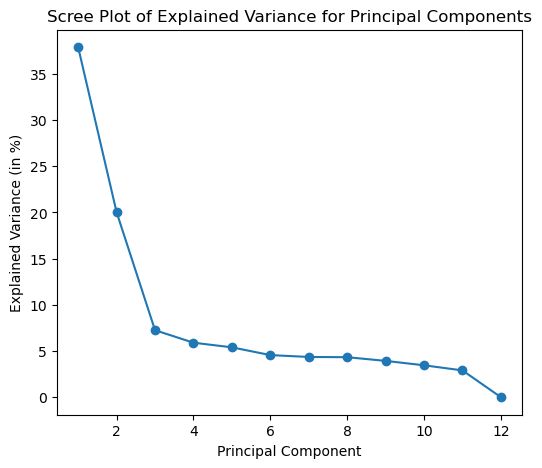

In [8]:
# Scree Plot
plt.figure(figsize=(6, 5))

# Create a scree plot to visualize the explained variance
plt.plot(
    range(1, len(explained_variance) + 1),  # x-axis
    explained_variance * 100,  # convert explained variance in percentage
    marker="o",  # add a marker at each value
)
plt.title("Scree Plot of Explained Variance for Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (in %)")

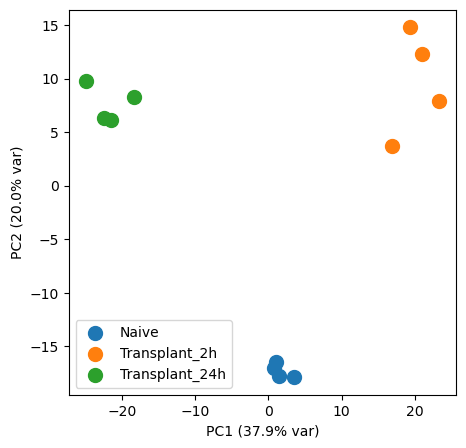

In [9]:
# PCA Scatter Plot
plt.figure(figsize=(5, 5))
for group in df_pca["Group"].unique():
    subset = df_pca[df_pca["Group"] == group]
    plt.scatter(subset["PC1"], subset["PC2"], label=group, s=100)

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.1f}% var)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.1f}% var)")
plt.legend()

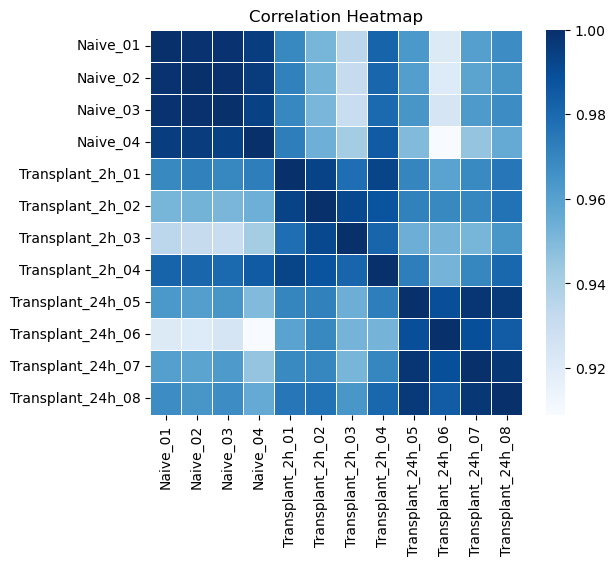

In [10]:
# Pearson’s correlation matrix. (Non-log-normalized data)
matrix = dfcounts.corr(method="pearson")

plt.figure(figsize=(6, 5))
sns.heatmap(matrix, cmap="Blues", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
matrix

,Naive_01,Naive_02,Naive_03,Naive_04,Transplant_2h_01,Transplant_2h_02,Transplant_2h_03,Transplant_2h_04,Transplant_24h_05,Transplant_24h_06,Transplant_24h_07,Transplant_24h_08
Naive_01,1.000000,0.998605,0.998904,0.995289,0.968874,0.951712,0.934768,0.981768,0.963030,0.921366,0.960611,0.967353
Naive_02,0.998605,1.000000,0.999315,0.995669,0.971632,0.952370,0.931663,0.980815,0.960934,0.920986,0.958462,0.964134
Naive_03,0.998904,0.999315,1.000000,0.993881,0.969752,0.951054,0.930399,0.979819,0.964288,0.924311,0.962516,0.967614
Naive_04,0.995289,0.995669,0.993881,1.000000,0.972842,0.954093,0.941326,0.984889,0.949738,0.908949,0.945258,0.955969
Transplant_2h_01,0.968874,0.971632,0.969752,0.972842,1.000000,0.993579,0.977967,0.992947,0.970156,0.959132,0.968436,0.975224
Transplant_2h_02,0.951712,0.952370,0.951054,0.954093,0.993579,1.000000,0.991518,0.987715,0.971813,0.968813,0.970075,0.976847
Transplant_2h_03,0.934768,0.931663,0.930399,0.941326,0.977967,0.991518,1.000000,0.981216,0.954318,0.952005,0.951850,0.964038
Transplant_2h_04,0.981768,0.980815,0.979819,0.984889,0.992947,0.987715,0.981216,1.000000,0.972697,0.952100,0.970098,0.980609
Transplant_24h_05,0.963030,0.960934,0.964288,0.949738,0.970156,0.971813,0.954318,0.972697,1.000000,0.989488,0.998017,0.996103
Transplant_24h_06,0.921366,0.920986,0.924311,0.908949,0.959132,0.968813,0.952005,0.952100,0.989488,1.000000,0.989101,0.984571


In [ ]:
# The most correlated and least correlated samples within each group
df_group1 = matrix[matrix.columns[:4]].replace(1.0, np.nan)
df_group2 = matrix[matrix.columns[4:8]].replace(1.0, np.nan)
df_group3 = matrix[matrix.columns[8:12]].replace(1.0, np.nan)

max_value = df_group1.max().max()


# print(
#     "Highest and lowest R-values, representing the most and lest correlated samples, within each group"
# )
# for group_name, group_df in zip(groups.unique(), [df_group1, df_group2, df_group3]):
#     print(f"{group_name}; Max: {group_df.max().max()} at ")


(np.float64(0.9993145922785558), [])

## Filtering


In [168]:
dfcounts

,Naive_01,Naive_02,Naive_03,Naive_04,Transplant_2h_01,Transplant_2h_02,Transplant_2h_03,Transplant_2h_04,Transplant_24h_05,Transplant_24h_06,Transplant_24h_07,Transplant_24h_08
0,66.567260,72.604388,67.217287,70.263406,70.839475,64.616903,69.642272,72.673890,68.579085,69.754822,68.286563,68.031853
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2.407605,2.163268,2.490079,1.593701,1.441733,1.002870,1.700592,1.666637,11.861413,13.541675,11.626514,9.789112
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.009852,0.005464,0.017368,0.014177,0.012641,0.000000,0.010085,0.011964,0.028890,0.015992,0.018193,0.018984
...,...,...,...,...,...,...,...,...,...,...,...,...
43425,32.809035,26.519881,34.973146,31.475015,51.564840,37.835977,47.385006,51.273461,18.273077,18.165204,16.438582,21.074037
43426,0.101010,0.224097,0.000000,0.218032,0.000000,0.000000,0.000000,0.122672,0.000000,0.040991,0.046634,0.048661
43427,0.154782,0.171696,0.090957,0.445465,0.132410,0.427628,0.237671,0.140981,0.056738,0.000000,0.178645,0.149130
43428,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


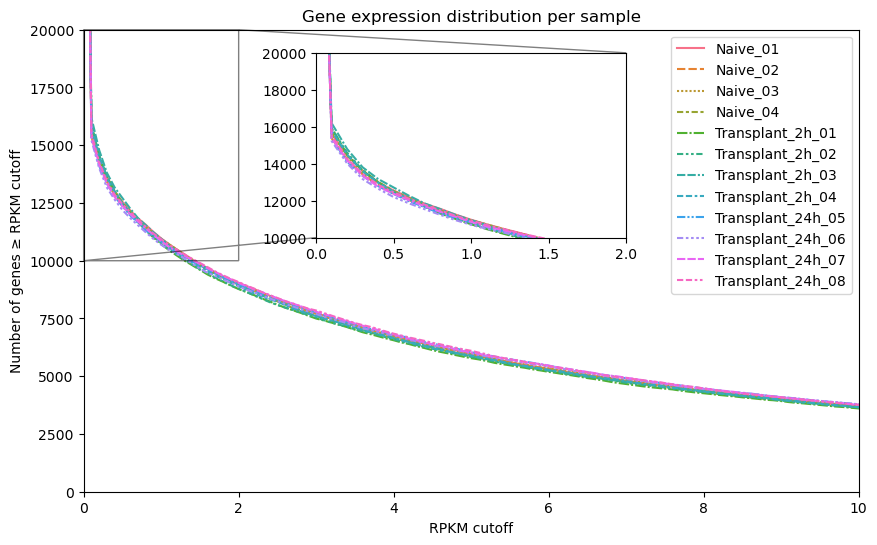

In [262]:
# Number of genes at a given RPKM value for each sample (bins = 120, bin size = 0.1)
# For example, Native_01 has 43430 values greater than 0.0, 15620 > 0.1 ... up to 11.9 (= 120 bins)

# Define bins and output df
rpkm_bins = np.arange(0, 12.1, 0.1)
rpkm_hist = pd.DataFrame(index=rpkm_bins[:-1])

# Compute counts of genes > cutoff
for col in dfcounts.columns:
    sorted_vals = np.sort(dfcounts[col].values)
    # For each cutoff, count how many genes >= cutoff
    rpkm_hist[col] = [(sorted_vals >= cutoff).sum() for cutoff in rpkm_bins[:-1]]


fig, ax = plt.subplots(figsize=(10, 6))
# Main plot
sns.lineplot(data=rpkm_hist, ax=ax)
ax.set_xlim([0, 10])
ax.set_ylim([0, 20000])
ax.set_xlabel("RPKM cutoff")
ax.set_ylabel("Number of genes ≥ RPKM cutoff")
ax.set_title("Gene expression distribution per sample")

# Define inset limits
x1, x2, y1, y2 = 0, 2, 10000, 20000

# Create inset axes inside main axes
axins = ax.inset_axes(
    [0.3, 0.55, 0.4, 0.4]
)  # [x0, y0, width, height] in relative coords
sns.lineplot(data=rpkm_hist, ax=axins, legend=False)

# Set zoom area in inset
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Indicate inset zoom region
ax.indicate_inset_zoom(axins, edgecolor="black")